<!--p align="center">
  <img src="https://drive.google.com/uc?export=view&id=1fi3-l8zVpLJj3wj3peImenJzMWBHpo7E" width="850">
</p-->

![image-2.png](./fine-tunning.png)


In [1]:
import gdown
import zipfile
import os

file_id = "1sEzPa5UvadV3Rh4VDuR9tdwvphQa-Af6"
url = f"https://drive.google.com/uc?id={file_id}"
output_zip = "butterfly.zip"

gdown.download(url, output_zip, quiet=False)

extract_dir = "./content"
with zipfile.ZipFile(output_zip, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

base_dir = os.path.join(extract_dir, "butterfly")
print("Contenido:", os.listdir(base_dir))

Downloading...
From: https://drive.google.com/uc?id=1sEzPa5UvadV3Rh4VDuR9tdwvphQa-Af6
To: /home/comejia/projects/ceia/ceia-computer-vision-ii/2026/Clase_3/Notebooks/butterfly.zip
100%|██████████| 6.43M/6.43M [00:00<00:00, 18.2MB/s]

Contenido: ['train', 'valid']


## Data augmentation

In [2]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import os
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

data_dir = "./content/butterfly"

train_dir = os.path.join(data_dir, "train")
valid_dir = os.path.join(data_dir, "valid")

train_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.CenterCrop(224),
        transforms.RandomHorizontalFlip(p=0.3),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
    ]
)

valid_transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ]
)

train_dataset = datasets.ImageFolder(root=train_dir, transform=train_transform)
valid_dataset = datasets.ImageFolder(root=valid_dir, transform=valid_transform)

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

classes = train_dataset.classes
print("Clases:", classes)
print("Num imágenes train:", len(train_dataset))
print("Num imágenes valid:", len(valid_dataset))

num_classes = len(classes)
print("Número de clases:", num_classes)

Device: cpu
Clases: ['AFRICAN GIANT SWALLOWTAIL', 'BECKERS WHITE', 'CATTLEHEART CELLED GREEN', 'CHESTNUT', 'DAPPLE EASTERN WHITE', 'DIAETHRIA ANNA', 'GREY HAIRSTREAK']
Num imágenes train: 433
Num imágenes valid: 159
Número de clases: 7


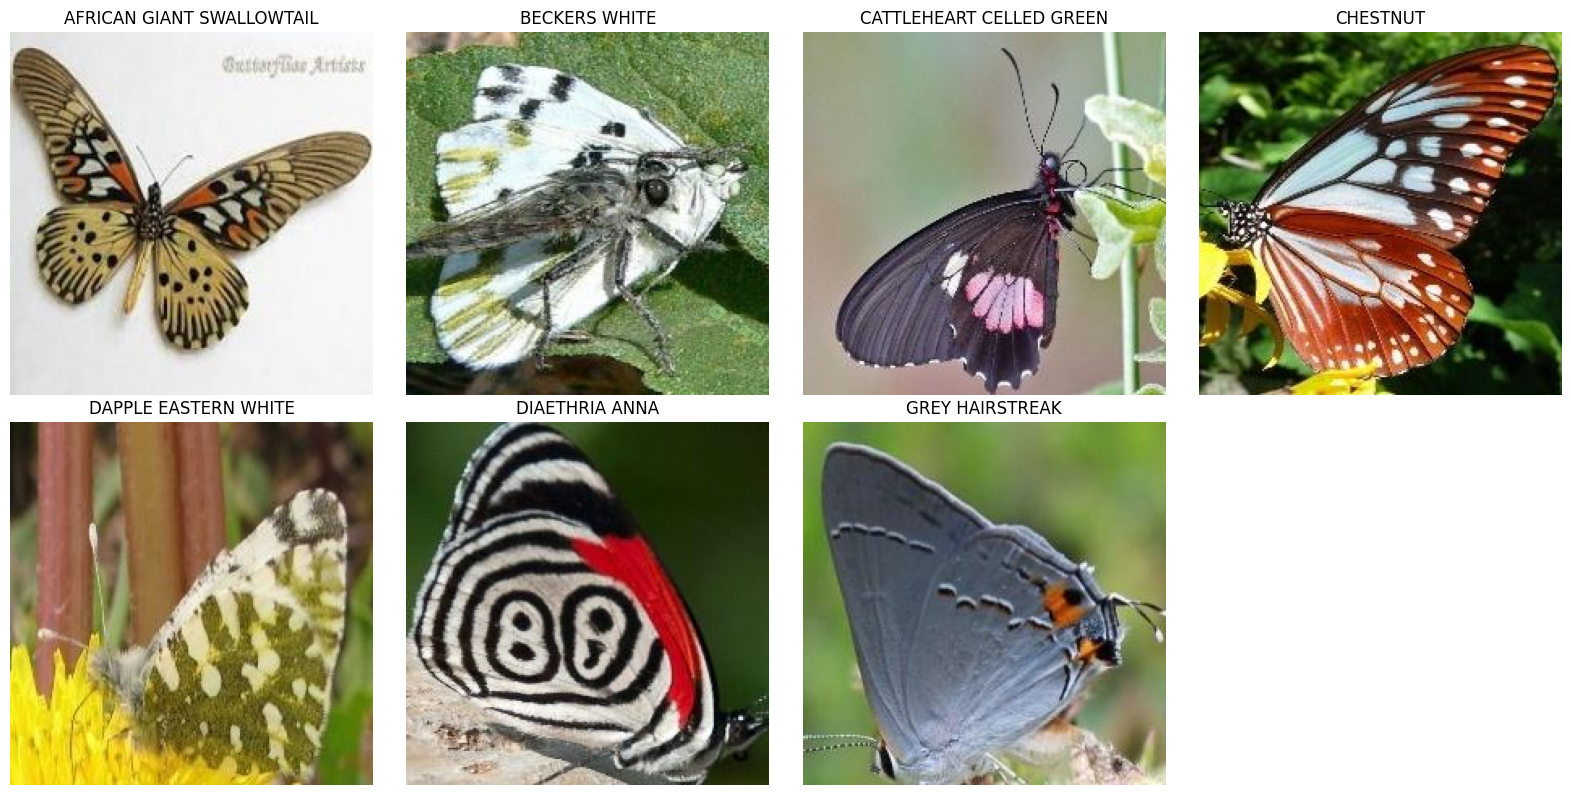

In [3]:
from PIL import Image


def show_random_images_per_class(dataset, transform, class_names):
    samples_per_class = {cls: [] for cls in class_names}

    for path, label in dataset.samples:
        samples_per_class[class_names[label]].append(path)

    num_classes = len(class_names)
    plt.figure(figsize=(16, 4 * ((num_classes + 3) // 4)))

    for idx, cls in enumerate(class_names):
        img_path = random.choice(samples_per_class[cls])
        img = Image.open(img_path).convert("RGB")

        img_tensor = transform(img)
        img_np = img_tensor.permute(1, 2, 0).numpy()

        plt.subplot((num_classes + 3) // 4, 4, idx + 1)
        plt.imshow(img_np)
        plt.title(cls)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_random_images_per_class(train_dataset, valid_transform, train_dataset.classes)

## Modelos Preentrenados

In [4]:
import torch.nn as nn
from torchvision.models import (
    alexnet,
    AlexNet_Weights,
    resnet50,
    ResNet50_Weights,
    efficientnet_v2_s,
)

In [5]:
# Iniciar con parámetros aleatorios
alexnet_random = alexnet(weights=None)
alexnet_random

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [6]:
# Iniciar con parámetros aleatorios
alexnet_random = alexnet(weights=None)
in_features = alexnet_random.classifier[-1].in_features
alexnet_random.classifier[-1] = nn.Linear(in_features, num_classes)
alexnet_random = alexnet_random.to(device)

# Iniciar con parámetros obtenidos con ImageNet
alexnet_ft = alexnet(weights=AlexNet_Weights.IMAGENET1K_V1)
in_features = alexnet_ft.classifier[-1].in_features
alexnet_ft.classifier[-1] = nn.Linear(in_features, num_classes)
alexnet_ft = alexnet_ft.to(device)

# Iniciar con parámetros obtenidos con ImageNet y congelarlos
alexnet_fe = alexnet(weights=AlexNet_Weights.IMAGENET1K_V1)
for p in alexnet_fe.parameters():
    p.requires_grad = False
in_features = alexnet_fe.classifier[-1].in_features
alexnet_fe.classifier[-1] = nn.Linear(in_features, num_classes)
for p in alexnet_fe.classifier[-1].parameters():
    p.requires_grad = True
alexnet_fe = alexnet_fe.to(device)

In [17]:
resnet_random = resnet50(weights=None)
resnet_random

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [19]:
# Iniciar con parámetros aleatorios
resnet_random = resnet50(weights=None)
in_features = resnet_random.fc.in_features
resnet_random.fc = nn.Linear(in_features, num_classes)
resnet_random = resnet_random.to(device)

# Iniciar con parámetros obtenidos con ImageNet
resnet_ft = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
in_features = resnet_ft.fc.in_features
resnet_ft.fc = nn.Linear(in_features, num_classes)
resnet_ft = resnet_ft.to(device)

# Iniciar con parámetros obtenidos con ImageNet y congelarlos
resnet_fe = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
for p in resnet_fe.parameters():
    p.requires_grad = False
in_features = resnet_random.fc.in_features
resnet_fe.fc = nn.Linear(in_features, num_classes)
for p in resnet_fe.fc.parameters():
    p.requires_grad = True
resnet_fe = resnet_fe.to(device)

In [20]:
# Iniciar con parámetros aleatorios
efnet_random = efficientnet_v2_s(weights=None)
in_features = efnet_random.classifier[-1].in_features
efnet_random.classifier[-1] = nn.Linear(in_features, num_classes)
efnet_random = efnet_random.to(device)

In [ ]:
import torch.optim as optim
from sklearn.metrics import f1_score


def entrenar_modelo(
    model, train_loader, val_loader, num_epochs=10, lr=1e-3, optimizer="Adam", device="cuda"
):
    """
    Entrena un modelo PyTorch con seguimiento de métricas.

    Parámetros:
        model        -> instancia del modelo (nn.Module)
        train_loader -> DataLoader para entrenamiento
        val_loader   -> DataLoader para validación
        num_epochs   -> número de épocas
        lr           -> learning rate
        device       -> 'cuda' o 'cpu'

    Retorna:
        history -> diccionario con loss, acc, f1 de train y val.
    """

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    parametros_para_optimizar = [p for p in model.parameters() if p.requires_grad]
    if optimizer == "Adam":
        optimizer = optim.Adam(parametros_para_optimizar, lr=lr)
    else:
        optimizer = optim.SGD(parametros_para_optimizar, lr=lr, momentum=0)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "train_f1": [],
        "val_f1": [],
    }

    for epoch in range(num_epochs):
        # ----------------------------------------
        # ENTRENAMIENTO
        # ----------------------------------------
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        preds_train = []
        labels_train = []

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * labels.size(0)
            _, predicted = torch.max(outputs, 1)

            correct += (predicted == labels).sum().item()
            total += labels.size(0)

            preds_train.extend(predicted.detach().cpu().numpy())
            labels_train.extend(labels.detach().cpu().numpy())

        train_loss = running_loss / total
        train_acc = correct / total
        train_f1 = f1_score(labels_train, preds_train, average="macro")

        # ----------------------------------------
        # VALIDACIÓN
        # ----------------------------------------
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        preds_val = []
        labels_val = []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * labels.size(0)
                _, predicted = torch.max(outputs, 1)

                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

                preds_val.extend(predicted.detach().cpu().numpy())
                labels_val.extend(labels.detach().cpu().numpy())

        val_loss /= val_total
        val_acc = val_correct / val_total
        val_f1 = f1_score(labels_val, preds_val, average="macro")

        # Guardar métricas
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)

        print(
            f"Epoch [{epoch + 1}/{num_epochs}] "
            f"Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}  "
            f"Train Acc: {train_acc:.4f}  Val Acc: {val_acc:.4f}  "
            f"Train F1: {train_f1:.4f}  Val F1: {val_f1:.4f}"
        )

    return history

In [11]:
def plot_history(num_epochs, history):
    epochs = range(1, num_epochs + 1)

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss por epoch")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, history["train_acc"], label="Train Acc")
    plt.plot(epochs, history["val_acc"], label="Val Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy por epoch")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(epochs, history["train_f1"], label="Train F1 macro")
    plt.plot(epochs, history["val_f1"], label="Val F1 macro")
    plt.xlabel("Epoch")
    plt.ylabel("F1 macro")
    plt.title("F1 macro por epoch")
    plt.legend()
    plt.grid(True)
    plt.show()

- **Entrenamiento desde cero**: se entrenan todos los pesos de la red por completo

Epoch [1/20] Train Loss: 2.0112  Val Loss: 1.9461  Train Acc: 0.1478  Val Acc: 0.1384  Train F1: 0.0807  Val F1: 0.0347
Epoch [2/20] Train Loss: 1.9450  Val Loss: 1.9483  Train Acc: 0.1316  Val Acc: 0.1384  Train F1: 0.0581  Val F1: 0.0347
Epoch [3/20] Train Loss: 1.9613  Val Loss: 1.8878  Train Acc: 0.1386  Val Acc: 0.1509  Train F1: 0.0930  Val F1: 0.0375
Epoch [4/20] Train Loss: 1.8553  Val Loss: 1.8503  Train Acc: 0.1871  Val Acc: 0.2830  Train F1: 0.1329  Val F1: 0.1216
Epoch [5/20] Train Loss: 1.8593  Val Loss: 1.5654  Train Acc: 0.1917  Val Acc: 0.3145  Train F1: 0.1110  Val F1: 0.1932
Epoch [6/20] Train Loss: 1.6151  Val Loss: 1.6262  Train Acc: 0.2841  Val Acc: 0.2579  Train F1: 0.2494  Val F1: 0.1484
Epoch [7/20] Train Loss: 1.4989  Val Loss: 1.4097  Train Acc: 0.2956  Val Acc: 0.3270  Train F1: 0.2379  Val F1: 0.2110
Epoch [8/20] Train Loss: 1.3833  Val Loss: 1.3728  Train Acc: 0.3857  Val Acc: 0.3522  Train F1: 0.3509  Val F1: 0.2823
Epoch [9/20] Train Loss: 1.2513  Val Los

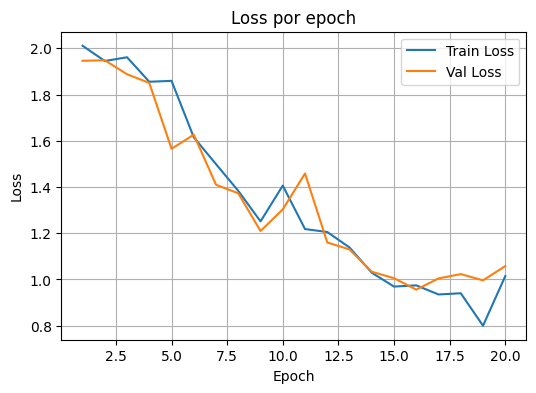

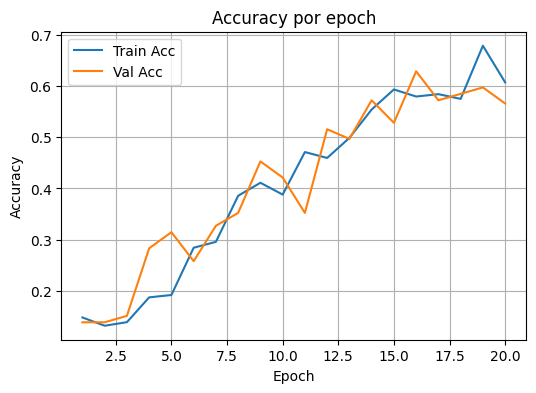

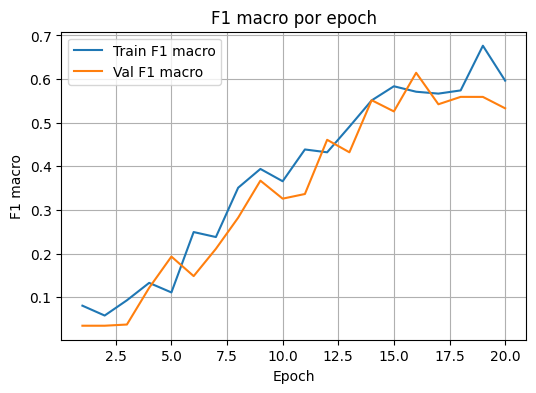

In [ ]:
# Iniciar con parámetros aleatorios
alexnet_random = alexnet(weights=None)
in_features = alexnet_random.classifier[-1].in_features
alexnet_random.classifier[-1] = nn.Linear(in_features, num_classes)
alexnet_random = alexnet_random.to(device)


num_epochs = 20
history_alexnet_random = entrenar_modelo(
    alexnet_random, train_loader, valid_loader, num_epochs, device="cpu"
)

plot_history(num_epochs, history_alexnet_random)

- **Fine tunning**: se utilizan los pesos pre-entrenados y se re-entrenan para ajustar a los nuevos datos.

📝 Adam es mejor cuando se entrena modelos desde cero, esto es porque asume que el punto optimo esta lejos por lo cual da saltos mas grandes en la busqueda. En cambio, para modelos donde se pretenda usar los pesos pre-entrenados, es conveniente utilizar otro optimizador, por ejemplo Gradient Descent. El GD como es menos "aventurero" va a optimizar a partir de los pesos pre-entrenados sin explorar otras zonas alejadas.

Epoch [1/20] Train Loss: 1.4945  Val Loss: 0.8832  Train Acc: 0.4942  Val Acc: 0.8491  Train F1: 0.4969  Val F1: 0.8513
Epoch [2/20] Train Loss: 0.7203  Val Loss: 0.5237  Train Acc: 0.8383  Val Acc: 0.8805  Train F1: 0.8397  Val F1: 0.8840
Epoch [3/20] Train Loss: 0.4564  Val Loss: 0.3848  Train Acc: 0.8961  Val Acc: 0.8931  Train F1: 0.8962  Val F1: 0.8974
Epoch [4/20] Train Loss: 0.3210  Val Loss: 0.2755  Train Acc: 0.9215  Val Acc: 0.9245  Train F1: 0.9216  Val F1: 0.9253
Epoch [5/20] Train Loss: 0.2467  Val Loss: 0.2789  Train Acc: 0.9423  Val Acc: 0.9119  Train F1: 0.9429  Val F1: 0.9141
Epoch [6/20] Train Loss: 0.2220  Val Loss: 0.2355  Train Acc: 0.9307  Val Acc: 0.9245  Train F1: 0.9314  Val F1: 0.9259
Epoch [7/20] Train Loss: 0.1725  Val Loss: 0.1665  Train Acc: 0.9538  Val Acc: 0.9308  Train F1: 0.9540  Val F1: 0.9317
Epoch [8/20] Train Loss: 0.1565  Val Loss: 0.1669  Train Acc: 0.9584  Val Acc: 0.9371  Train F1: 0.9587  Val F1: 0.9376
Epoch [9/20] Train Loss: 0.1476  Val Los

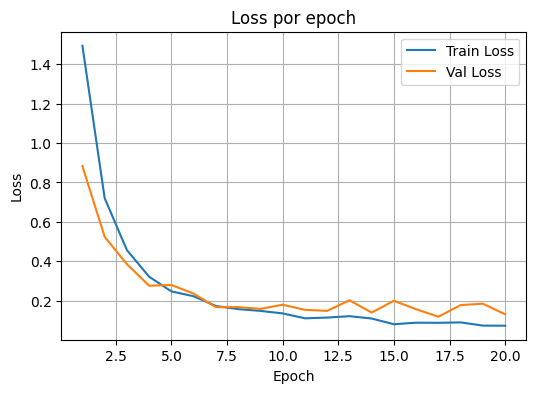

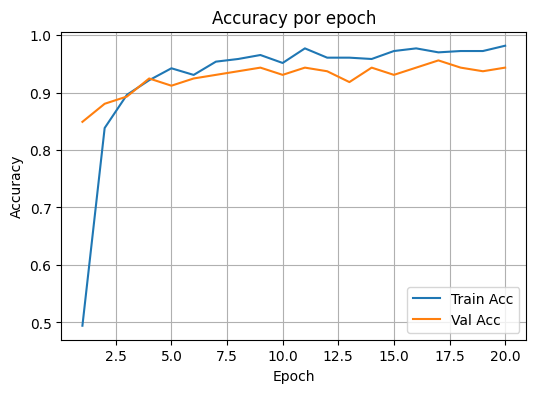

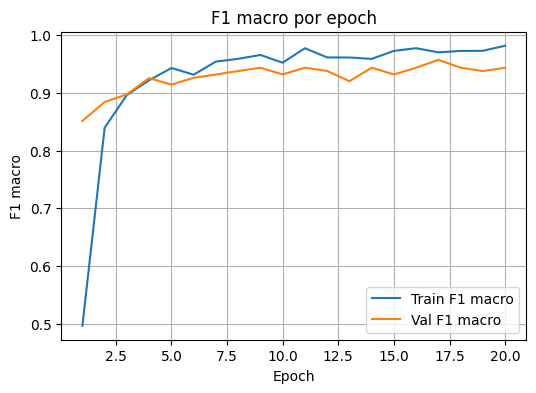

In [13]:
# Iniciar con parámetros obtenidos con ImageNet
alexnet_ft = alexnet(weights=AlexNet_Weights.IMAGENET1K_V1)
in_features = alexnet_ft.classifier[-1].in_features
alexnet_ft.classifier[-1] = nn.Linear(in_features, num_classes)
alexnet_ft = alexnet_ft.to(device)


num_epochs = 20
history_alexnet_ft = entrenar_modelo(
    alexnet_ft, train_loader, valid_loader, num_epochs, optimizer="SGD", device="cpu"
)

plot_history(num_epochs, history_alexnet_ft)

- **Feature extraction**: Solo se entrenan las últimas capas de la red. En las capas anteriores se congelan los pesos

Epoch [1/20] Train Loss: 0.7532  Val Loss: 0.2436  Train Acc: 0.7667  Val Acc: 0.9119  Train F1: 0.7731  Val F1: 0.9144
Epoch [2/20] Train Loss: 0.1745  Val Loss: 0.1784  Train Acc: 0.9353  Val Acc: 0.9371  Train F1: 0.9365  Val F1: 0.9380
Epoch [3/20] Train Loss: 0.1136  Val Loss: 0.2067  Train Acc: 0.9654  Val Acc: 0.9308  Train F1: 0.9656  Val F1: 0.9325
Epoch [4/20] Train Loss: 0.1091  Val Loss: 0.1537  Train Acc: 0.9654  Val Acc: 0.9434  Train F1: 0.9655  Val F1: 0.9440
Epoch [5/20] Train Loss: 0.0987  Val Loss: 0.1674  Train Acc: 0.9607  Val Acc: 0.9308  Train F1: 0.9611  Val F1: 0.9325
Epoch [6/20] Train Loss: 0.0923  Val Loss: 0.1307  Train Acc: 0.9630  Val Acc: 0.9497  Train F1: 0.9636  Val F1: 0.9496
Epoch [7/20] Train Loss: 0.0671  Val Loss: 0.1783  Train Acc: 0.9723  Val Acc: 0.9308  Train F1: 0.9722  Val F1: 0.9325
Epoch [8/20] Train Loss: 0.0606  Val Loss: 0.1862  Train Acc: 0.9838  Val Acc: 0.9371  Train F1: 0.9840  Val F1: 0.9384
Epoch [9/20] Train Loss: 0.0665  Val Los

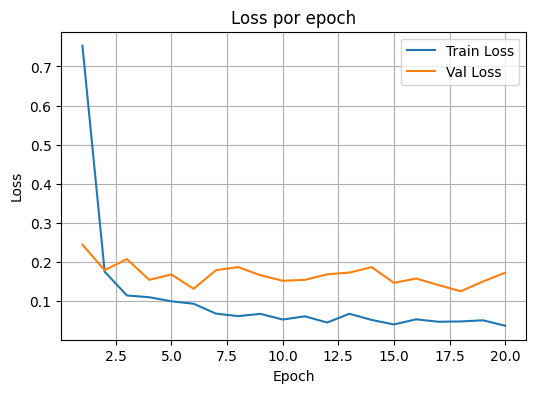

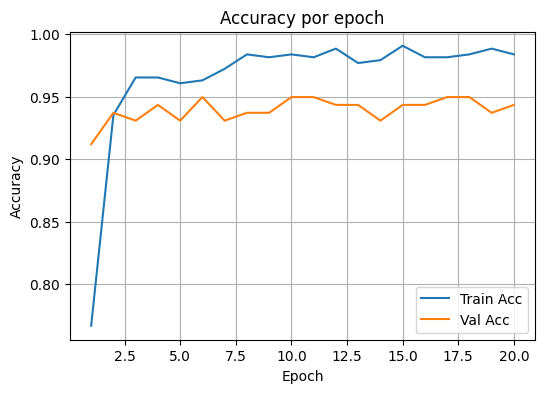

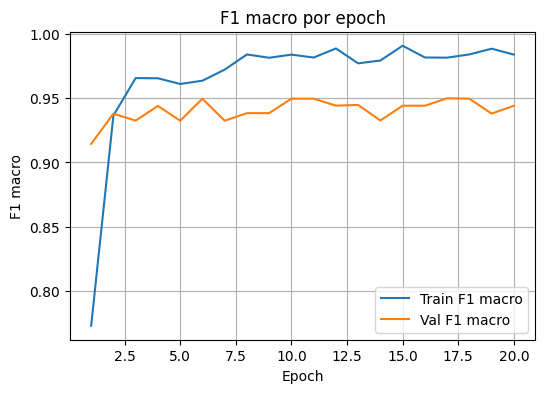

In [14]:
num_epochs = 20
history_alexnet_fe = entrenar_modelo(
    alexnet_fe, train_loader, valid_loader, num_epochs, device="cpu"
)


plot_history(num_epochs, history_alexnet_fe)

* Entrenamiento usando Resnet

Epoch [1/20] Train Loss: 1.6635  Val Loss: 1.1063  Train Acc: 0.3880  Val Acc: 0.7673  Train F1: 0.3947  Val F1: 0.7644
Epoch [2/20] Train Loss: 0.8817  Val Loss: 0.6423  Train Acc: 0.8106  Val Acc: 0.8428  Train F1: 0.8008  Val F1: 0.8539
Epoch [3/20] Train Loss: 0.5050  Val Loss: 0.3891  Train Acc: 0.9030  Val Acc: 0.9245  Train F1: 0.9040  Val F1: 0.9161
Epoch [4/20] Train Loss: 0.3507  Val Loss: 0.2828  Train Acc: 0.9492  Val Acc: 0.9686  Train F1: 0.9494  Val F1: 0.9688
Epoch [5/20] Train Loss: 0.2684  Val Loss: 0.2662  Train Acc: 0.9792  Val Acc: 0.9560  Train F1: 0.9791  Val F1: 0.9576
Epoch [6/20] Train Loss: 0.2227  Val Loss: 0.2149  Train Acc: 0.9746  Val Acc: 0.9560  Train F1: 0.9746  Val F1: 0.9553
Epoch [7/20] Train Loss: 0.2024  Val Loss: 0.1951  Train Acc: 0.9654  Val Acc: 0.9560  Train F1: 0.9656  Val F1: 0.9573
Epoch [8/20] Train Loss: 0.1653  Val Loss: 0.1751  Train Acc: 0.9746  Val Acc: 0.9560  Train F1: 0.9745  Val F1: 0.9561
Epoch [9/20] Train Loss: 0.1530  Val Los

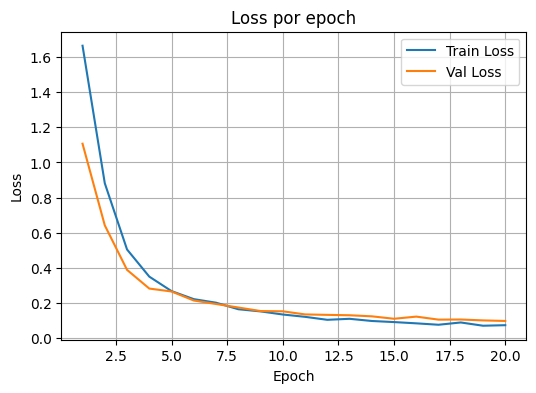

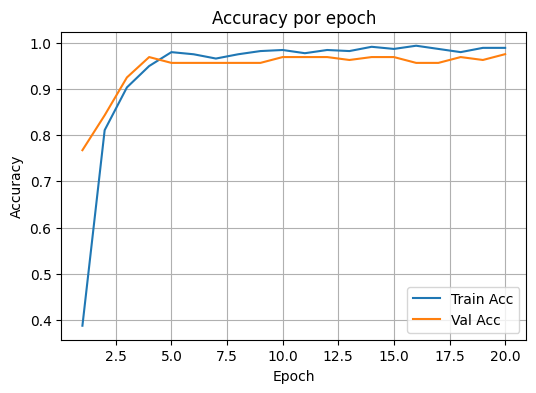

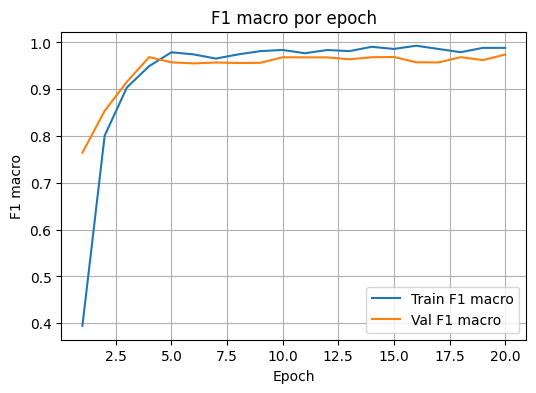

In [15]:
num_epochs = 20
history_resnet_fe = entrenar_modelo(resnet_fe, train_loader, valid_loader, num_epochs, device="cpu")


plot_history(num_epochs, history_resnet_fe)

* Inferencia

Predicción: CHESTNUT (91.24 %)


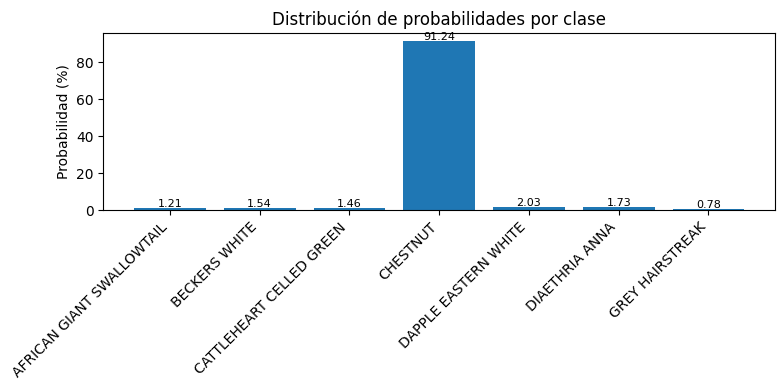

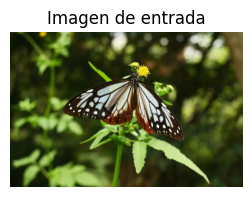

In [23]:
import numpy as np

inference_transform = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])


def infer_image(path_img, model, classes):
    model.eval()
    img = Image.open(path_img).convert("RGB")
    x = inference_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(x)
        probs = torch.softmax(outputs, dim=1)[0].cpu().numpy()

    predicted_idx = int(np.argmax(probs))
    predicted_class = classes[predicted_idx]

    print(f"Predicción: {predicted_class} ({probs[predicted_idx] * 100:.2f} %)")

    plt.figure(figsize=(8, 4))
    plt.bar(np.arange(len(classes)), probs * 100)
    plt.xticks(np.arange(len(classes)), classes, rotation=45, ha="right")
    plt.ylabel("Probabilidad (%)")
    plt.title("Distribución de probabilidades por clase")

    for i, p in enumerate(probs * 100):
        plt.text(i, p + 0.5, f"{p:.2f}", ha="center", fontsize=8)

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis("off")
    plt.title("Imagen de entrada")
    plt.show()


infer_image("./mariposa-chestnut.png", alexnet_ft, classes)